# Lógica difusa para Python 3

Los doctests de los módulos deberían dar una buena idea de cómo usar las cosas por sí mismas, mientras que aquí hay algunos ejemplos de cómo usar todo junto.

# Instalación
Lo primero es lo primero: Para instalar fuzzylogic, sólo tienes que introducir `python -m pip install fuzzylogic` y ¡listo!

In [12]:
!pip install fuzzylogic[plotting]

zsh:1: no matches found: fuzzylogic[plotting]


In [9]:
!python -m pip install matplotlib pandas

### Funciones y conjuntos
Definir un dominio con su rango y resolución debería ser trivial, ya que la mayoría de los instrumentos del mundo real vienen con esas especificaciones. Sin embargo, definir los conjuntos difusos dentro de esos dominios es donde empieza la diversión, ya que sólo un humano puede decir si algo está "caliente" o "no", ¿verdad?

¿Por qué esta distinción? Las funciones sólo asignan valores, no tienen nada de especial, lo que es bueno para las pruebas y el rendimiento. Los conjuntos, por otro lado, implementan operaciones lógicas que tienen una sintaxis especial de Python, lo que hace que sea fácil trabajar con ellos, pero un poco más difícil de probar y añade algo de sobrecarga de rendimiento. Por lo tanto, los conjuntos son para la abstracción y el fácil manejo, las funciones para el rendimiento.

### Dominios
Puedes usar (yo lo hago regularmente) funciones difusas fuera de cualquier contexto difuso específico. Sin embargo, si quieres aprovechar la lógica de los conjuntos difusos, graficar cosas o defuzzyfy valores, necesitas usar Dominios. Los Dominios y los Conjuntos son especiales en el sentido de que dependen intrínsecamente el uno del otro. Esto es forzado por como funcionan las asignaciones. Los atributos regulares de Dominio son los conjuntos que fueron asignados al dominio. Además, si sólo se asigna una función, ésta se envuelve automáticamente en un conjunto.

In [1]:
from fuzzylogic.classes import Domain
from fuzzylogic.functions import R, S, alpha

T = Domain("test", 0, 30, res=0.1)

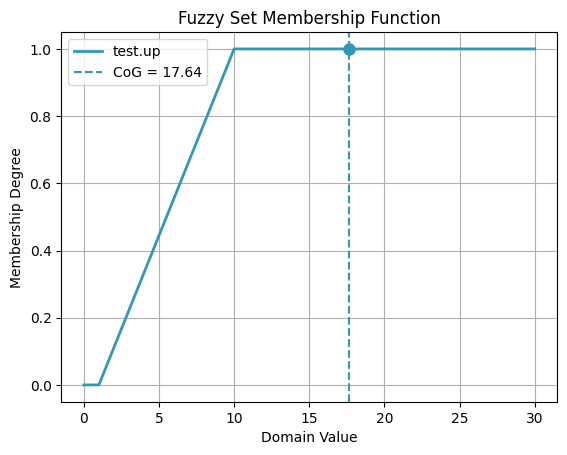

In [2]:
T.up = R(1,10)
T.up.plot()

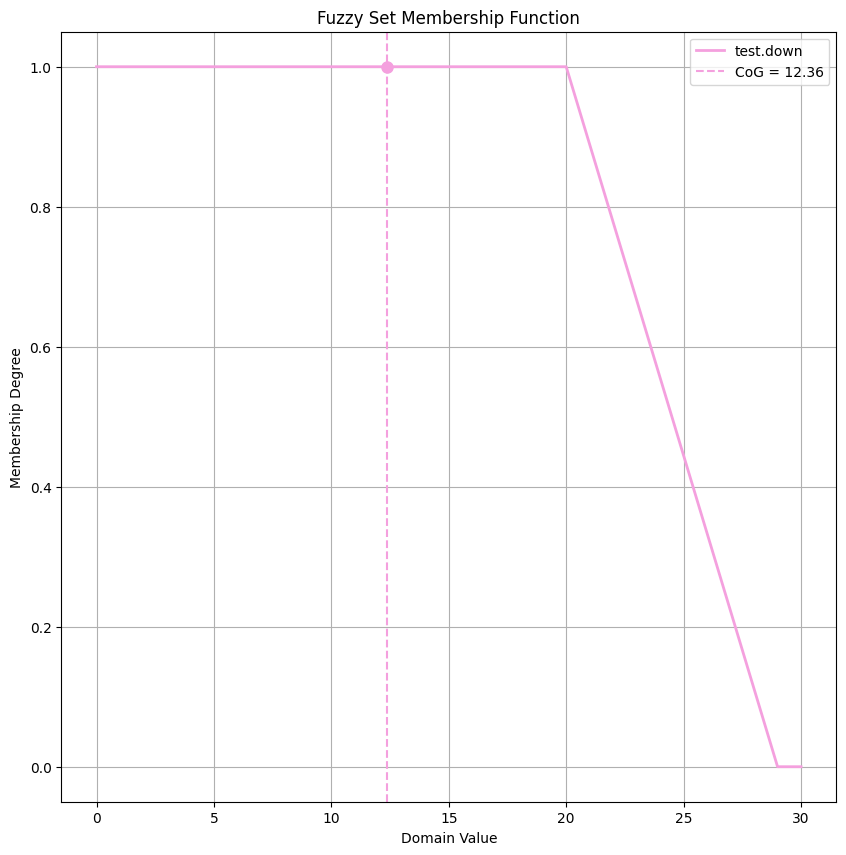

In [7]:
T.down = S(20, 29)
T.down.plot()

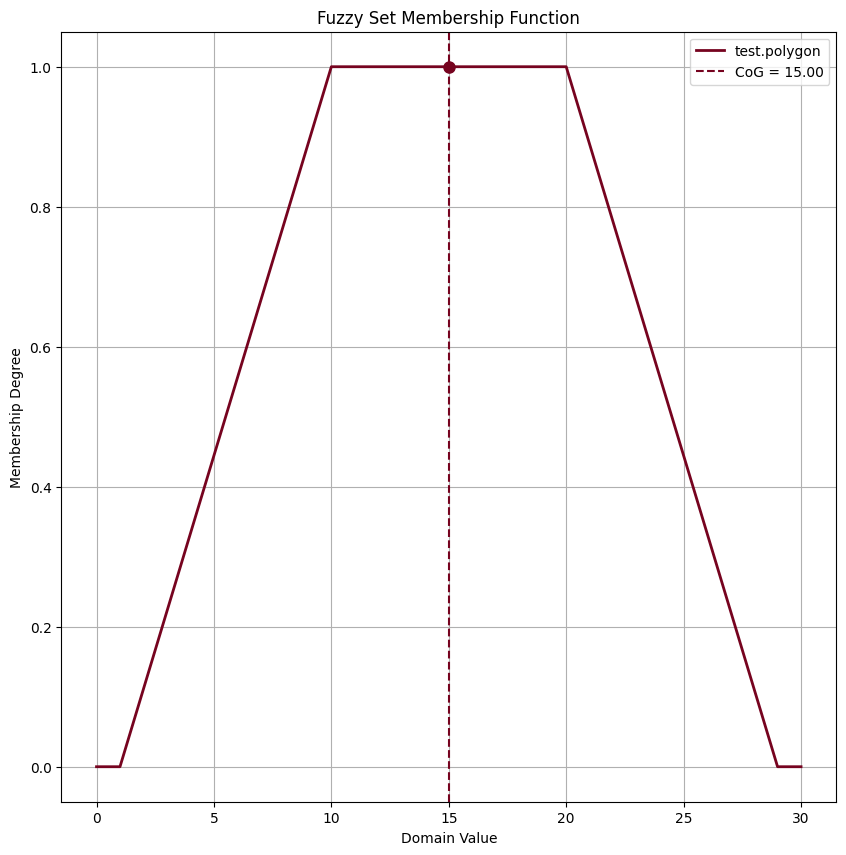

In [8]:
T.polygon = T.up & T.down
T.polygon.plot()

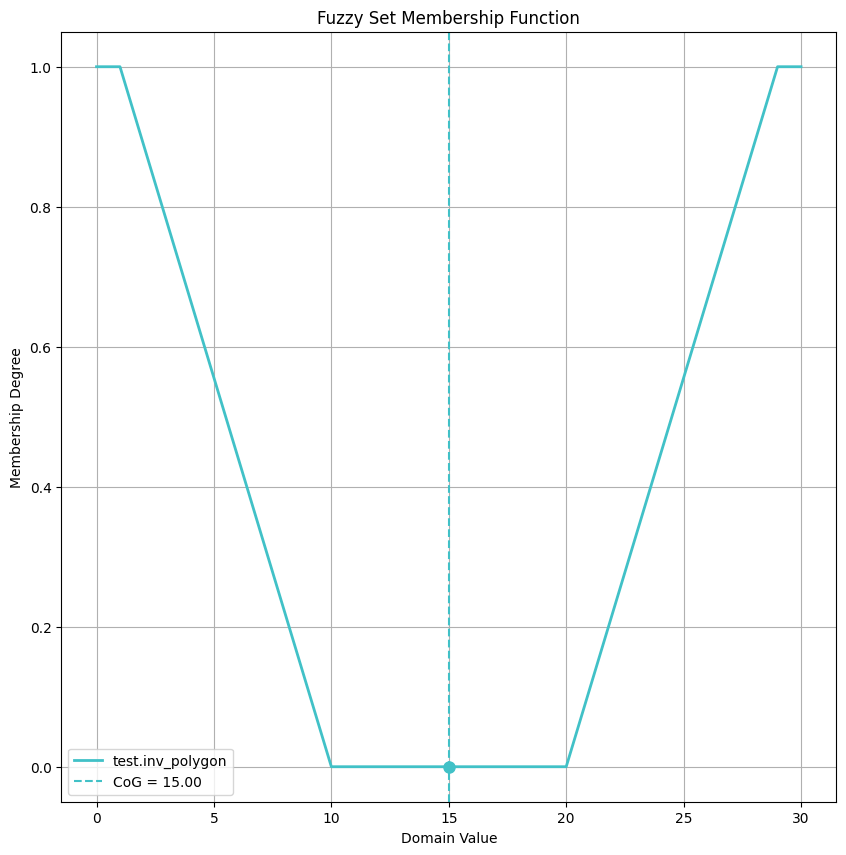

In [9]:
T.inv_polygon = ~T.polygon
T.inv_polygon.plot()

vamos a mostrar algunas funciones interesantes ;)

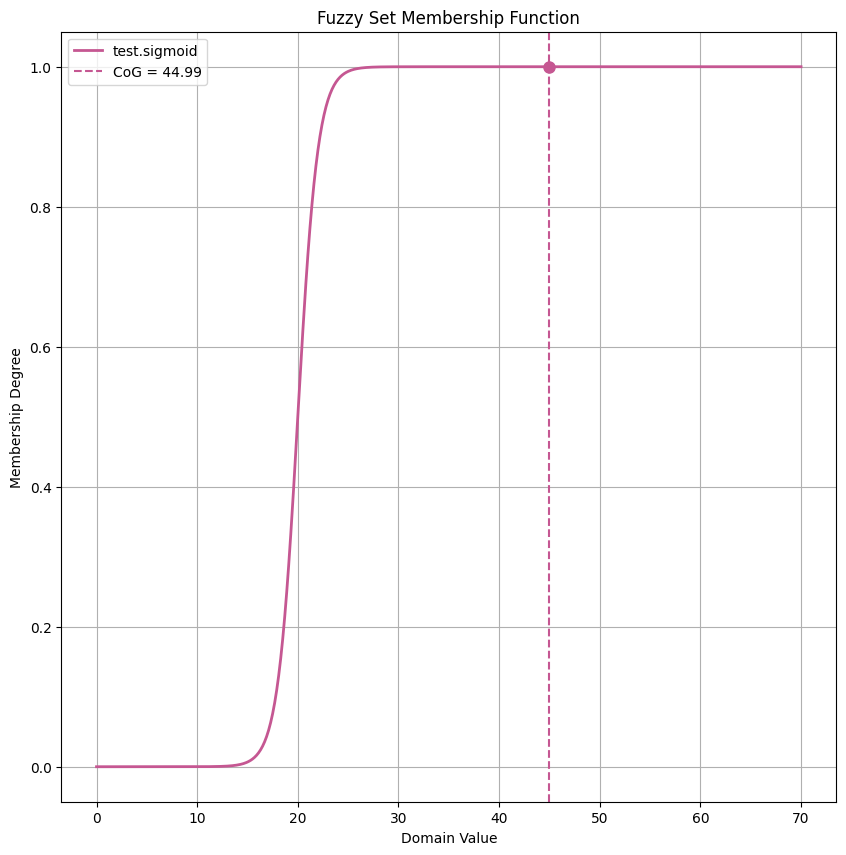

In [13]:
from fuzzylogic.classes import Domain, Set
from fuzzylogic.functions import (sigmoid, gauss, trapezoid, 
                             triangular_sigmoid, rectangular)

T = Domain("test", 0, 70, res=0.1)
T.sigmoid = sigmoid(1,1,20)
T.sigmoid.plot()
# T.gauss = gauss(10, 0.01, c_m=0.9)
# T.gauss.plot()
# T.trapezoid = trapezoid(25, 30, 35, 40, c_m=0.9)
# T.trapezoid.plot()
# T.triangular_sigmoid = triangular_sigmoid(40, 70, c=55)
# T.triangular_sigmoid.plot()

### Dominios

Tras especificar el dominio y asignar conjuntos, al llamar a un dominio con un valor se devuelve un dictado de pertenencias de los conjuntos de ese dominio.

{numbers.foo: 0.5443310539518174}

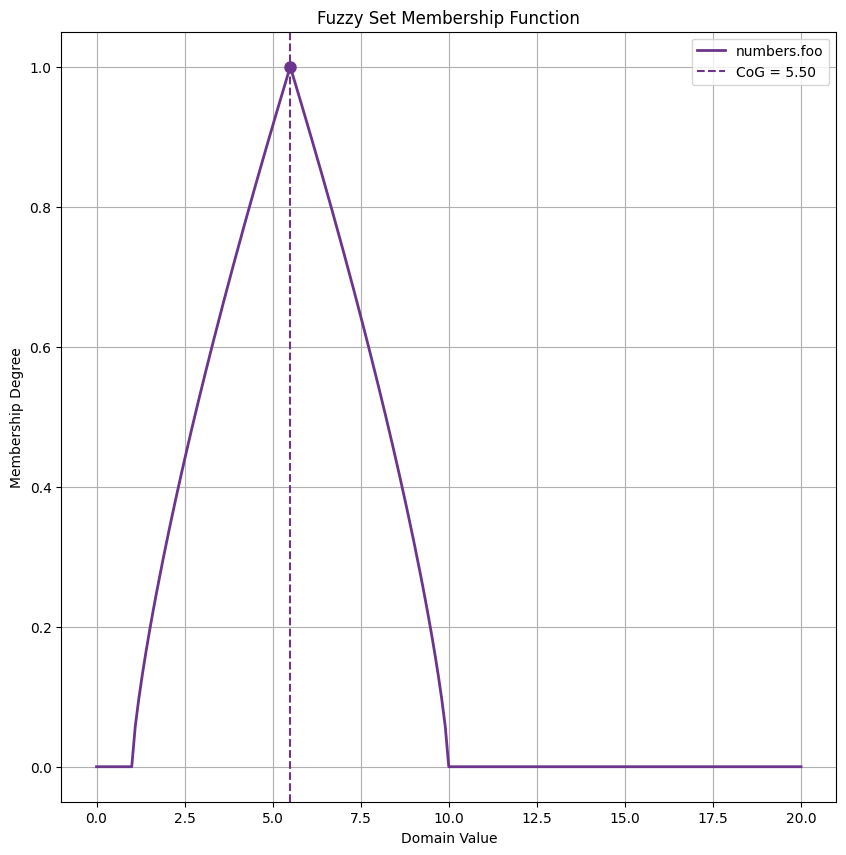

In [15]:
from fuzzylogic.classes import Domain
from fuzzylogic.functions import alpha, triangular
from fuzzylogic.hedges import plus, minus, very

numbers = Domain("numbers", 0, 20, res=0.1)

# close_to_10 = alpha(floor=0.2, ceiling=0.8, func=triangular(0, 20))
close_to_5 = triangular(1, 10)

numbers.foo = minus(close_to_5)
# numbers.bar = very(close_to_10)

# numbers.bar.plot()
numbers.foo.plot()
# numbers.baz = numbers.foo + numbers.bar
# numbers.baz.plot()

numbers(8)

{temperature.cold: 0.5,
 temperature.hot: 0.012195121951219511,
 temperature.warm: 0.5}

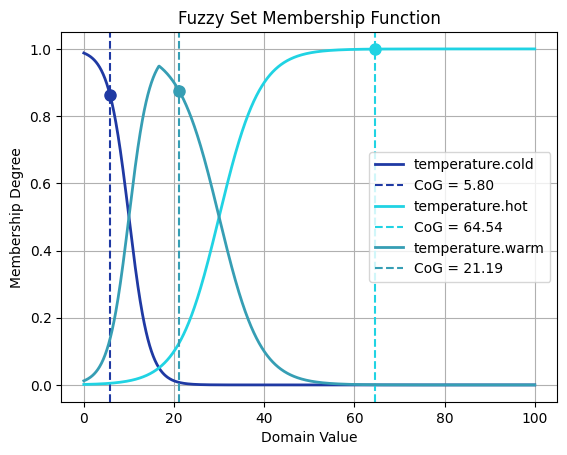

In [3]:
from fuzzylogic.classes import Domain
from fuzzylogic.functions import bounded_sigmoid

T = Domain("temperature", 0, 100, res=0.1)
T.cold = bounded_sigmoid(5,15, inverse=True)
T.cold.plot()
T.hot = bounded_sigmoid(20, 40)
T.hot.plot()
T.warm = ~T.hot & ~T.cold
T.warm.plot()
T(10)

Muchas veces terminas con conjuntos que nunca llegan a 1 como con sigmoides, funciones triangulares que llegan a la frontera del dominio o después de operaciones con otros conjuntos. Entonces suele ser necesario normalizar (definir max(set) == 1). Tenga en cuenta que Set.normalized() devuelve un conjunto que (a diferencia de otras operaciones con conjuntos) ya está vinculado al dominio y recibe el nombre "normalized_{set.name}". Esto no se puede eludir porque la normalización sólo se define en un dominio dado.

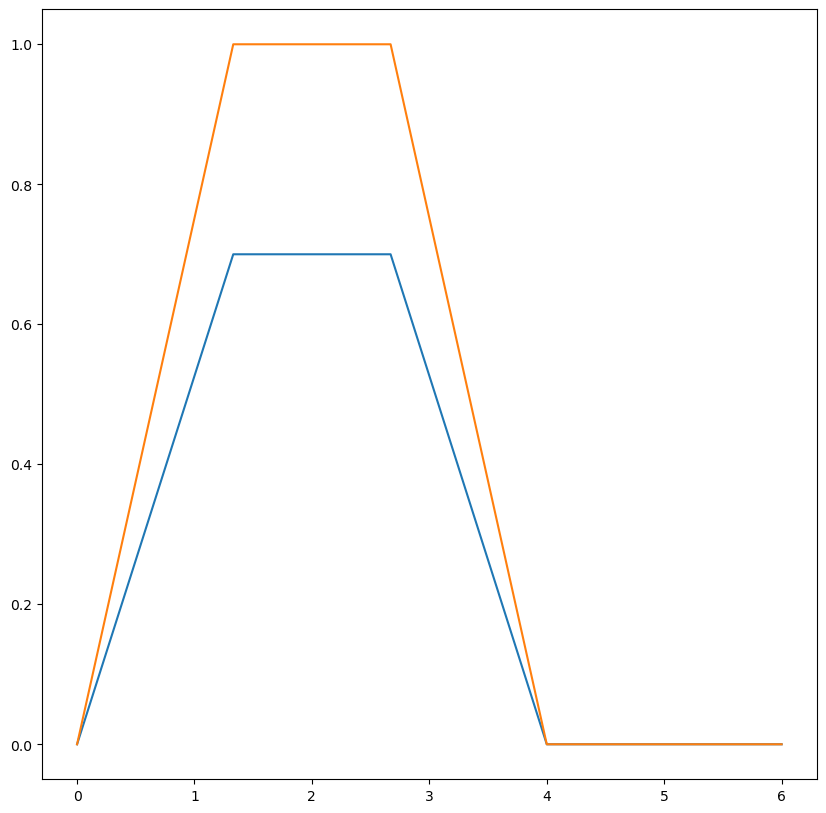

In [10]:
from fuzzylogic.classes import Domain
from fuzzylogic.functions import alpha, trapezoid

N = Domain("numbers", 0, 6, res=0.01)
N.two_or_so = alpha(floor=0, ceiling=0.7, func=trapezoid(0, 1.9, 2.1, 4))
N.two_or_so.plot()
N.x = N.two_or_so.normalized()
N.x.plot()

### Inferencia

Tras medir un valor RL y asignarlo a conjuntos dentro de un dominio, normalmente es necesario traducir el resultado a otro dominio que corresponda a algún tipo de mecanismo de control. Esta traducción o mapeo se denomina inferencia y tiene su origen en la operación de conclusión lógica A => B, por ejemplo Si llueve, la calle está mojada. La calle puede estar mojada por varias razones, pero si llueve estará mojada con toda seguridad. Este **IF A THEN B** también se puede escribir como ***(A AND B) OR NOT(A AND TRUE)***. Esto puede parecer sencillo para la lógica booleana, pero ya que no estamos tratando sólo con Verdadero y Falso, hay un número de maneras en la lógica difusa para realmente implementar esto.

Aquí hay un ejemplo simple pero completamente funcional con todas las partes móviles, demostrando el uso en el contexto de un sistema HVAC.

También demuestra las tres formas diferentes de establecer combinaciones complejas de reglas: puedes definir cada regla una por una y luego combinarlas mediante el operador |, o puedes poner las reglas en una lista y usar sum(..) para combinarlas en una sola en un solo paso, o puedes definir una regla grande y compleja desde el principio. La forma que mejor se adapte a tus necesidades dependerá de lo compleja que sea cada regla y de cómo/dónde las definas en tu código y de si necesitas utilizarlas en distintos lugares en distintas combinaciones.

In [14]:
from fuzzylogic.classes import Domain, Set, Rule
from fuzzylogic.hedges import very
from fuzzylogic.functions import R, S

temp = Domain("Temperature", -80, 80)
hum = Domain("Humidity", 0, 100)
motor = Domain("Speed", 0, 2000)

temp.cold = S(0,20)
temp.hot = R(15,30)

hum.dry = S(20,50)
hum.wet = R(40,70)

motor.fast = R(1000,1500)
motor.slow = ~motor.fast

R1 = Rule({(temp.hot, hum.dry): motor.fast})
R2 = Rule({(temp.cold, hum.dry): very(motor.slow)})
R3 = Rule({(temp.hot, hum.wet): very(motor.fast)})
R4 = Rule({(temp.cold, hum.wet): motor.slow})

rules = Rule({(temp.hot, hum.dry): motor.fast,
              (temp.cold, hum.dry): very(motor.slow),
              (temp.hot, hum.wet): very(motor.fast),
              (temp.cold, hum.wet): motor.slow,
             })

rules == R1 | R2 | R3 | R4 == sum([R1, R2, R3, R4])

values = {hum: 45, temp: 22}
print(R1(values), R2(values), R3(values), R4(values), "=>", rules(values))

1611.3704197201866 None 1656.5076659966692 None => 1633.939042858428


Hay que tener en cuenta algunas cosas en este ejemplo. En primer lugar, asegúrese de pasar los valores como un único diccionario al final, no como parámetros. Si una regla tiene peso cero - en este ejemplo una temp de 22 resulta en frío ponderado con S(0,20) como 0 - la Regla devuelve Ninguno, lo que asegura que esta condición sea ignorada en los cálculos posteriores. También puede notar que el resultado es un valor de 1633, que es mucho más de lo que motor.fast con R(1000,1500) sugeriría. Sin embargo, como el dominio motor está definido entre 0 y 2000, el método del centro de gravedad utilizado para la evaluación tiene en cuenta muchos de los valores entre 1500 y 2000 ponderados con 1, dando este resultado ligeramente inesperado.

Escribir una sola Regla o unas pocas de esta manera es explícito y sencillo de entender, pero considerando sólo 2 variables de entrada con 3 Conjuntos cada una, esto ya significa 9 líneas de código, con cada elemento repetido 3 veces. Además, la mayoría de recursos como libros presentan estas reglas como tablas u hojas de cálculo, que pueden ser excesivamente complicadas o al menos molestas de reescribir como Reglas explícitas. Para ayudar en estos casos, he añadido la posibilidad de transformar tablas 2D en Reglas. Esta funcionalidad utiliza pandas para importar una tabla escrita como cadena multilínea por ahora, pero sería fácil aceptar hojas de cálculo Excel, csv y todos los demás formatos soportados por pandas. Sin embargo, esta funcionalidad viene con tres inconvenientes potenciales: El contenido de las celdas son cadenas - que no tiene soporte IDE (por lo que los errores tipográficos podrían colarse), que son eval()ed - lo que puede suponer un riesgo de seguridad si la tabla es proporcionada por una fuente no fiable. En tercer lugar, sólo las reglas con 2 variables de entrada pueden ser modeladas de esta manera, a diferencia de las reglas "clásicas" que permiten un número ilimitado de variables de entrada.

Tenga en cuenta que el segundo argumento de esta función debe ser el espacio de nombres en el que están definidos todos los dominios, conjuntos y coberturas que se utilizan en la tabla. Esto se debe al hecho de que la evaluación de esos nombres en realidad ocurre en un módulo donde esos nombres normalmente no están definidos.

In [16]:
table = """
            hum.dry             hum.wet
temp.cold   very(motor.slow)    motor.slow
temp.hot    motor.fast          very(motor.fast)
"""
from fuzzylogic.classes import rule_from_table
table_rules = rule_from_table(table, globals())
assert table_rules == rules

Como puede ver, la tabla_reglas anterior es igual a las reglas construidas antes de una en una, pero mucho menos verbosa. No ha habido que repetir ningún elemento y es mucho más fácil de leer.

## Bibliografía
* Showcase de la libreria FuzzyLogic
* Fuzzy Logic and Control: Software and Hardware Applications, Volume 2

      By: Mohammad Jamshidi; Nader Vadiee; Timothy J. Ross - University of New Mexico
      Publisher: Prentice Hall
      Pub. Date: June 07, 1993
      
* Computational Intelligence - Fuzzy-Tutorial
      
      Prof. Dr. habil. A. Grauel
      
* http://petro.tanrei.ca/fuzzylogic/fuzzy_negnevistky.html
* http://kik.informatik.fh-dortmund.de/abschlussarbeiten/fuzzyControl/operatoren.html
*     Fundamentals of Fuzzy Logic Control – Fuzzy Sets, Fuzzy Rules and Defuzzifications

    Ying Bai and Dali Wang
    
    https://www.researchgate.net/profile/Ying_Bai/publication/225872318_Fundamentals_of_Fuzzy_Logic_Control_-_Fuzzy_Sets_Fuzzy_Rules_and_Defuzzifications/links/0fcfd5057a874858b1000000/Fundamentals-of-Fuzzy-Logic-Control-Fuzzy-Sets-Fuzzy-Rules-and-Defuzzifications.pdf
